# Play a checkpoint

Loads a trained RL checkpoint, runs it live in DMLab for a few episodes, and saves (1) an mp4 of the agent's first-person view at native 60Hz and (2) a top-down trajectory plot in the style of Fig. 2h/i. Inference-only -- no training, no optimizer, no gradients. All the model-reconstruction logic lives in `rl_train.py` (`build_models_from_checkpoint`, `grid_step_velocity_only`, `draw_hud`); this notebook only drives it.

In [1]:
import os
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

import deepmind_lab
from config import Config
from actor_critic import DISCRETE_ACTIONS
from rl_train import build_models_from_checkpoint, grid_step_velocity_only, draw_hud, world_to_meters

CHECKPOINT = "data/checkpoints/rl_baseline/checkpoint_step7813000.pt"
EPISODES = 1
MAX_FRAMES = 1800  # 30s at 60Hz, per episode
VIDEO_SIZE = 336
FPS = 60
OUT_DIR = Path("results/presentation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

t_start = time.time()

cfg = Config()
ckpt = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
grid_network, vision_module, actor_critic, place, hd, has_rl_lstm, ego_vel_dim = \
    build_models_from_checkpoint(ckpt, cfg)


/root/anaconda3/lib/python3.13/site-packages/deepmind_lab/__init__.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loaded checkpoint at step 7813000 -- grid network has vision input: True, ego_vel_dim: 4


## Run episodes, recording frames + position at native 60Hz

In [2]:
env_cfg = cfg.rl.env
level_dir = os.path.abspath(env_cfg.level_directory)
env = deepmind_lab.Lab(
    env_cfg.level,
    ["RGB_INTERLEAVED", "VEL.TRANS", "VEL.ROT", "DEBUG.POS.TRANS", "DEBUG.POS.ROT"],
    config={"width": str(VIDEO_SIZE), "height": str(VIDEO_SIZE), "levelDirectory": level_dir},
)


def observe():
    obs = env.observations()
    big_rgb = obs["RGB_INTERLEAVED"].copy()
    small = np.asarray(Image.fromarray(big_rgb).resize((64, 64), Image.BILINEAR))
    image64 = torch.from_numpy(small).permute(2, 0, 1).float() / 127.5 - 1.0
    pos_m = world_to_meters(torch.from_numpy(obs["DEBUG.POS.TRANS"][:2].copy()).float(), env_cfg)
    vel_trans = torch.from_numpy(obs["VEL.TRANS"].copy()).float()
    vel_rot = torch.from_numpy(obs["VEL.ROT"].copy()).float()
    return image64, pos_m, vel_trans, vel_rot


def ego_vel_from(vel_trans, vel_rot):
    scale = env_cfg.env_size_m / (env_cfg.wall_world_units[1] - env_cfg.wall_world_units[0])
    dt = env_cfg.action_repeat / 60.0
    dtheta = vel_rot[1] * dt * torch.pi / 180.0
    trig = [torch.sin(dtheta).unsqueeze(0), torch.cos(dtheta).unsqueeze(0)]
    if ego_vel_dim == 4:
        ego_vel = torch.cat([vel_trans[0].unsqueeze(0) * scale, vel_trans[1].unsqueeze(0) * scale] + trig)
    else:
        ego_vel = torch.cat([vel_trans[:2].norm().unsqueeze(0) * scale] + trig)
    return ego_vel + torch.randn_like(ego_vel) * env_cfg.velocity_noise_std


torch.manual_seed(0)
frames, positions, goal_frame_idx, start_pos = [], [], None, None

for ep in range(EPISODES):
    env.reset(seed=ep)
    image64, pos_m, vel_trans, vel_rot = observe()
    if start_pos is None:
        start_pos = pos_m.clone()
    positions.append(pos_m.clone())

    grid_hidden = grid_network.init_hidden_from_predictions(
        [torch.zeros(1, place.n_cells), torch.zeros(1, hd.n_cells)])
    ac_hidden = actor_critic.init_hidden(1)
    prev_action = torch.zeros(1, dtype=torch.long)
    goal_grid_code = torch.zeros(1, cfg.model.nh_bottleneck)
    reward_t = torch.zeros(1, 1)
    cumulative_reward = 0.0

    while env.is_running() and len(frames) < MAX_FRAMES:
        ego_vel = ego_vel_from(vel_trans, vel_rot).unsqueeze(0)
        with torch.no_grad():
            vision_out = vision_module(image64.unsqueeze(0))
            if has_rl_lstm:
                vision_t = torch.cat([vision_out.place_probs, vision_out.hd_probs], dim=-1)
                grid_code, grid_hidden = grid_network.step(ego_vel, vision_t, grid_hidden)
            else:
                grid_code, grid_hidden = grid_step_velocity_only(grid_network, ego_vel, grid_hidden)
            ac_out = actor_critic.step(image64.unsqueeze(0), reward_t, prev_action,
                                       grid_code, goal_grid_code, ac_hidden)
            ac_hidden = ac_out.hidden
            action_idx = torch.distributions.Categorical(logits=ac_out.action_logits).sample()

        macro_reward = 0.0
        for _ in range(env_cfg.action_repeat):
            if not env.is_running() or len(frames) >= MAX_FRAMES:
                break
            r = env.step(DISCRETE_ACTIONS[action_idx.item()], num_steps=1)
            macro_reward += float(r)
            cumulative_reward += float(r)
            if not env.is_running():
                break
            sub_obs = env.observations()
            frame = draw_hud(sub_obs["RGB_INTERLEAVED"].copy(), ep, len(frames) / FPS, cumulative_reward)
            frames.append(frame)
            pos_now = world_to_meters(torch.from_numpy(sub_obs["DEBUG.POS.TRANS"][:2].copy()).float(), env_cfg)
            positions.append(pos_now.clone())
            if r > 0 and goal_frame_idx is None:
                goal_frame_idx = len(frames) - 1

        if macro_reward > 0:
            goal_grid_code = grid_code.detach()
        reward_t = torch.tensor([[macro_reward]], dtype=torch.float32)

        if not env.is_running() or len(frames) >= MAX_FRAMES:
            break
        image64, pos_m, vel_trans, vel_rot = observe()
        prev_action = action_idx

    print(f"episode {ep}: {len(frames)} frames so far, cumulative_reward={cumulative_reward:.0f}")

env.close()
positions = torch.stack(positions).numpy()
t_env = time.time()
print(f"env+inference: {t_env - t_start:.1f}s for {len(frames)} frames ({len(frames) / FPS:.1f}s of footage)")


/tmp/ipykernel_9512/4020894193.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  image64 = torch.from_numpy(small).permute(2, 0, 1).float() / 127.5 - 1.0


episode 0: 1800 frames so far, cumulative_reward=0
env+inference: 15.2s for 1800 frames (30.0s of footage)


## Save video

In [3]:
import imageio
import imageio_ffmpeg
import matplotlib as mpl
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

video_path = OUT_DIR / f"playthrough_step{ckpt['step']}_{len(frames)}f.mp4"
writer = imageio.get_writer(str(video_path), fps=FPS, codec="libx264",
                            ffmpeg_params=["-pix_fmt", "yuv420p"])
for f in frames:
    writer.append_data(f)
writer.close()
t_video = time.time()
print(f"video encode: {t_video - t_env:.1f}s -- saved {video_path}")


Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


video encode: 1.7s -- saved results/presentation/playthrough_step7813000_1800f.mp4


## Trajectory (Fig. 2h/i style)

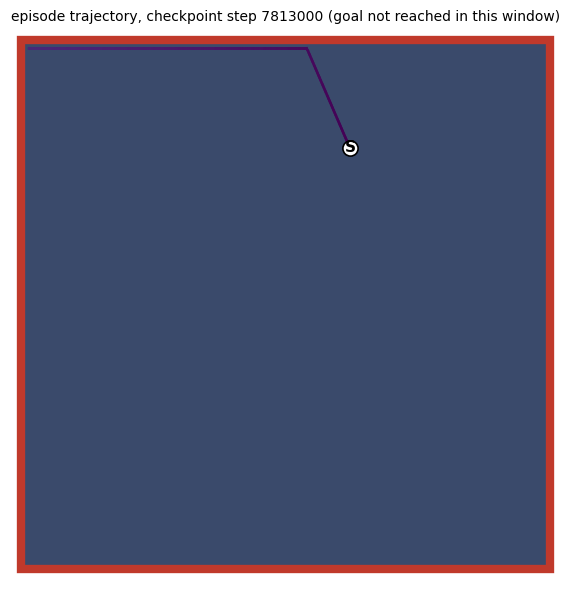

saved results/presentation/trajectory_step7813000.png
total notebook time: 18.1s


In [4]:
half = env_cfg.env_size_m / 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Rectangle((-half, -half), env_cfg.env_size_m, env_cfg.env_size_m,
                           facecolor="#3a4a6b", edgecolor="#c0392b", linewidth=6, zorder=0))

colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))
for i in range(len(positions) - 1):
    ax.plot(positions[i:i + 2, 0], positions[i:i + 2, 1], color=colors[i], lw=1.8, zorder=1)

ax.scatter(*start_pos.numpy(), color="white", s=120, zorder=3, edgecolor="k", linewidth=1.2)
ax.annotate("S", start_pos.numpy(), color="black", fontsize=11, fontweight="bold",
           ha="center", va="center", zorder=4)

if goal_frame_idx is not None:
    goal_pos = positions[goal_frame_idx + 1]
    ax.scatter(*goal_pos, color="gold", s=160, zorder=3, edgecolor="k", linewidth=1.2, marker="*")
    ax.annotate("Goal", goal_pos, color="white", fontsize=10, fontweight="bold",
               xytext=(0, 12), textcoords="offset points", ha="center", zorder=4)
    title_suffix = f"goal reached at t={goal_frame_idx / FPS:.1f}s"
else:
    title_suffix = "goal not reached in this window"

ax.set_xlim(-half - 0.05, half + 0.05)
ax.set_ylim(-half - 0.05, half + 0.05)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"episode trajectory, checkpoint step {ckpt['step']} ({title_suffix})", fontsize=10)
fig.tight_layout()

traj_path = OUT_DIR / f"trajectory_step{ckpt['step']}.png"
fig.savefig(traj_path, dpi=150, bbox_inches="tight")
plt.show()

t_end = time.time()
print(f"saved {traj_path}")
print(f"total notebook time: {t_end - t_start:.1f}s")
